# ⭐ Импорты

In [1]:
import numpy as np
import pandas as pd
from sklift.datasets import fetch_hillstrom
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree

from upninja.models.Trees.UpliftTreeClassifier import UpliftTreeClassifier
from upninja.models.Trees.UpliftTreeClassifierDML import UpliftTreeClassifierDML

# causalml
from causalml.inference.tree import UpliftTreeClassifier as UpliftTreeClassifierCM
from causalml.metrics import plot_gain

from sklift.metrics import qini_auc_score, uplift_at_k

import matplotlib.pyplot as plt

/Users/romanseleznyov/Documents/UpliftNinja/uplift-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/romanseleznyov/Documents/UpliftNinja/uplift-env/lib/python3.13/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Failed to import duecredit due to No module named 'duecredit'


In [2]:
SEED = 42

# ⭐ Fetch & Preproc

In [3]:
data = fetch_hillstrom(target_col='visit')
df = data.data
X, y, w = df, data.target, data.treatment

# Hillstrom: treatment — 'Mens E-Mail', 'Womens E-Mail' -> объединим в бинарный treatment
w = (w != 'No E-Mail').astype(int)  # 1 — получили email, 0 — нет

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=SEED
)

num_cols = X_train.select_dtypes(exclude='object').columns
X_train = X_train[num_cols]
X_test = X_test[num_cols]

# for causalml
X_np = X[num_cols].values
y_np = y.values
X_train_np, X_test_np, y_train_np, y_test_np, w_train_str, w_test_str = (
    X_train.values, X_test.values,
    y_train.values, y_test.values,
    np.where(w_train == 1, 'treatment', 'control'),
    np.where(w_test == 1, 'treatment', 'control')
)

In [4]:
df.shape

(64000, 8)

# ⭐ DML Tree

In [5]:
%%time

tree_dml = UpliftTreeClassifierDML(
    min_samples=100,
    max_depth=5,
    min_samples_treatment=5,
    random_state=SEED
)

tree_dml.fit(X_train, y_train, w_train)
pred_tree_dml_test = tree_dml.predict(X_test)
pred_tree_dml_train = tree_dml.predict(X_train)
pred_tree_dml_all = tree_dml.predict(X[num_cols])

CPU times: user 62.2 ms, sys: 1.79 ms, total: 64 ms
Wall time: 63.7 ms


In [6]:
print("=== Метрики ===")
print("TEST:")
print(f"Upninja DML Tree — Qini AUC: {qini_auc_score(y_test, pred_tree_dml_test, w_test):.4f}")
print("TRAIN:")
print(f"Upninja DML Tree — Qini AUC: {qini_auc_score(y_train, pred_tree_dml_train, w_train):.4f}")
print("ALL:")
print(f"Upninja DML Tree — Qini AUC: {qini_auc_score(y, pred_tree_dml_all, w):.4f}")

print(f"\nUplift@30%:")
print("TEST:")
print(f"Upninja DML Tree: {uplift_at_k(y_test, pred_tree_dml_test, w_test, strategy='by_group', k=0.3):.4f}")
print("TRAIN:")
print(f"Upninja DML Tree: {uplift_at_k(y_train, pred_tree_dml_train, w_train, strategy='by_group', k=0.3):.4f}")
print("ALL:")
print(f"Upninja DML Tree: {uplift_at_k(y, pred_tree_dml_all, w, strategy='by_group', k=0.3):.4f}")

print(f"\nСредний uplift:")
print("TEST:")
print(f"Upninja DML Tree: {pred_tree_dml_test.mean():.4f}")
print("TRAIN:")
print(f"Upninja DML Tree: {pred_tree_dml_train.mean():.4f}")
print("ALL:")
print(f"Upninja DML Tree: {pred_tree_dml_all.mean():.4f}")

=== Метрики ===
TEST:
Upninja DML Tree — Qini AUC: 0.0520
TRAIN:
Upninja DML Tree — Qini AUC: 0.0454
ALL:
Upninja DML Tree — Qini AUC: 0.0466

Uplift@30%:
TEST:
Upninja DML Tree: 0.0941
TRAIN:
Upninja DML Tree: 0.0789
ALL:
Upninja DML Tree: 0.0784

Средний uplift:
TEST:
Upninja DML Tree: 0.0586
TRAIN:
Upninja DML Tree: 0.0591
ALL:
Upninja DML Tree: 0.0590


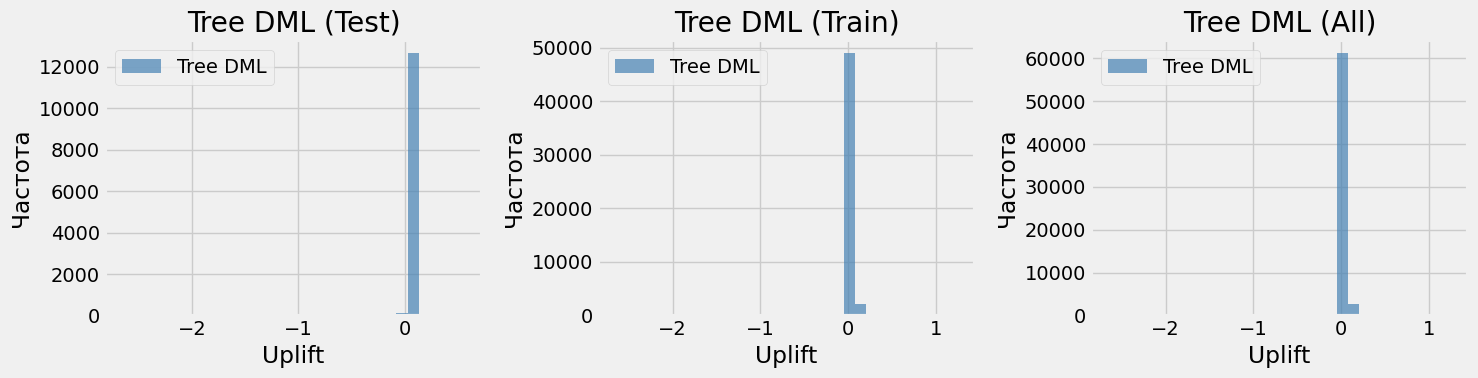

In [7]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(pred_tree_dml_test, bins=30, alpha=0.7, color='steelblue', label='Tree DML')
plt.title('Tree DML (Test)')
plt.xlabel('Uplift')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(pred_tree_dml_train, bins=30, alpha=0.7, color='steelblue', label='Tree DML')
plt.title('Tree DML (Train)')
plt.xlabel('Uplift')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(pred_tree_dml_all, bins=30, alpha=0.7, color='steelblue', label='Tree DML')
plt.title('Tree DML (All)')
plt.xlabel('Uplift')
plt.ylabel('Частота')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
results_test = pd.DataFrame({
    'tree_dml_test': pred_tree_dml_test
})

results_train = pd.DataFrame({
    'tree_dml_train': pred_tree_dml_train
})

results_all = pd.DataFrame({
    'tree_dml_all': pred_tree_dml_all
})
    
actual_treatment_test = np.where(w_test == 1, 'treatment', 'control')
is_control_test = (actual_treatment_test == 'control').astype(int)

gain_df_tree_dml_test = pd.DataFrame({
    'conversion': y_test.to_numpy(),
    'is_treated': 1 - is_control_test,
    'uplift': results_test['tree_dml_test']
})

actual_treatment_train = np.where(w_train == 1, 'treatment', 'control')
is_control_train = (actual_treatment_train == 'control').astype(int)

gain_df_tree_dml_train = pd.DataFrame({
    'conversion': y_train.to_numpy(),
    'is_treated': 1 - is_control_train,
    'uplift': results_train['tree_dml_train']
})

actual_treatment_all = np.where(w == 1, 'treatment', 'control')
is_control_all = (actual_treatment_all == 'control').astype(int)

gain_df_tree_dml_all = pd.DataFrame({
    'conversion': y.to_numpy(),
    'is_treated': 1 - is_control_all,
    'uplift': results_all['tree_dml_all']
})

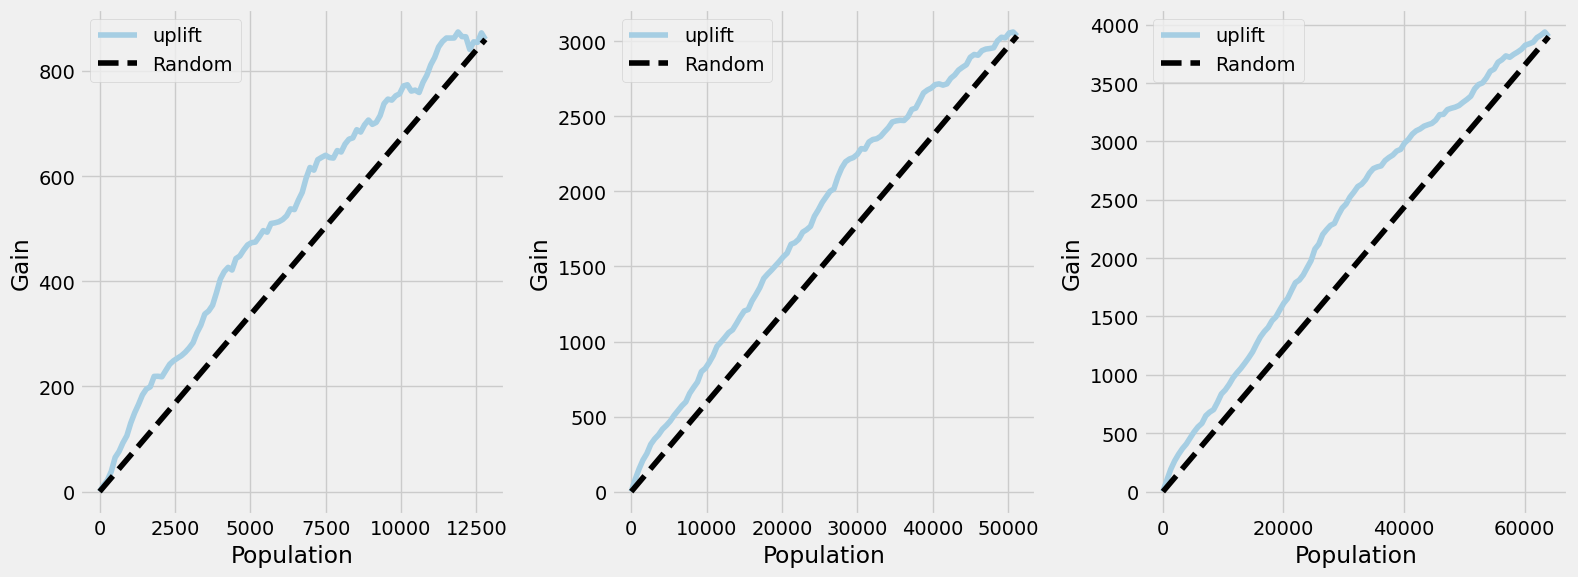

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

plot_gain(gain_df_tree_dml_test,
          outcome_col='conversion',
          treatment_col='is_treated',
          ax=axes[0])

plot_gain(gain_df_tree_dml_train,
          outcome_col='conversion',
          treatment_col='is_treated',
          ax=axes[1])

plot_gain(gain_df_tree_dml_all,
          outcome_col='conversion',
          treatment_col='is_treated',
          ax=axes[2])

plt.tight_layout()
plt.show()

In [10]:
print("=== Финансовый эффект ===")
effect_df = pd.DataFrame({
    'y': y,
    'w': w,
    'uplift': pred_tree_dml_all
})

top_k = int(0.3 * len(effect_df))
top_df = effect_df.nlargest(top_k, 'uplift')

y_t = top_df[top_df['w'] == 1]['y'].mean()
y_c = top_df[top_df['w'] == 0]['y'].mean()
empirical_uplift = y_t - y_c

n_t = (top_df['w'] == 1).sum()
additional_purchases = empirical_uplift * n_t

print(f"Дополнительные покупки: {additional_purchases:.2f}")

=== Финансовый эффект ===
Дополнительные покупки: 1101.91


# ⭐ Causal Tree

In [11]:
%%time

causalml_tree = UpliftTreeClassifierCM(
    max_depth=5,
    min_samples_leaf=100,
    random_state=SEED,
    control_name='control'
)

causalml_tree.fit(X_train_np, w_train_str, y_train_np)
pred_causalml_tree_test = causalml_tree.predict(X_test_np)[:, 0]
pred_causalml_tree_train = causalml_tree.predict(X_train_np)[:, 0]
pred_causalml_tree_all = causalml_tree.predict(X_np)[:, 0]

CPU times: user 160 ms, sys: 1.85 ms, total: 162 ms
Wall time: 162 ms


In [12]:
print("=== Метрики ===")
print("TEST:")
print(f"Causalml Tree — Qini AUC: {qini_auc_score(y_test_np, pred_causalml_tree_test.flatten(), w_test):.4f}")
print("TRAIN:")
print(f"Causalml Tree — Qini AUC: {qini_auc_score(y_train_np, pred_causalml_tree_train.flatten(), w_train):.4f}")
print("ALL:")
print(f"Causalml Tree — Qini AUC: {qini_auc_score(y_np, pred_causalml_tree_all.flatten(), w):.4f}")

print(f"\nUplift@30%:")
print("TEST:")
print(f"Causalml: {uplift_at_k(y_test_np, pred_causalml_tree_test.flatten(), w_test, strategy='by_group', k=0.3):.4f}")
print("TRAIN:")
print(f"Causalml: {uplift_at_k(y_train_np, pred_causalml_tree_train.flatten(), w_train, strategy='by_group', k=0.3):.4f}")
print("ALL:")
print(f"Causalml: {uplift_at_k(y_np, pred_causalml_tree_all.flatten(), w, strategy='by_group', k=0.3):.4f}")

print(f"\nСредний uplift:")
print("TEST:")
print(f"Causalml: {pred_causalml_tree_test.mean():.4f}")
print("TRAIN:")
print(f"Causalml: {pred_causalml_tree_train.mean():.4f}")
print("ALL:")
print(f"Causalml: {pred_causalml_tree_all.mean():.4f}")

=== Метрики ===
TEST:
Causalml Tree — Qini AUC: 0.0468
TRAIN:
Causalml Tree — Qini AUC: -0.0070
ALL:
Causalml Tree — Qini AUC: 0.0037

Uplift@30%:
TEST:
Causalml: 0.1035
TRAIN:
Causalml: 0.0602
ALL:
Causalml: 0.0724

Средний uplift:
TEST:
Causalml: 0.1072
TRAIN:
Causalml: 0.1077
ALL:
Causalml: 0.1076


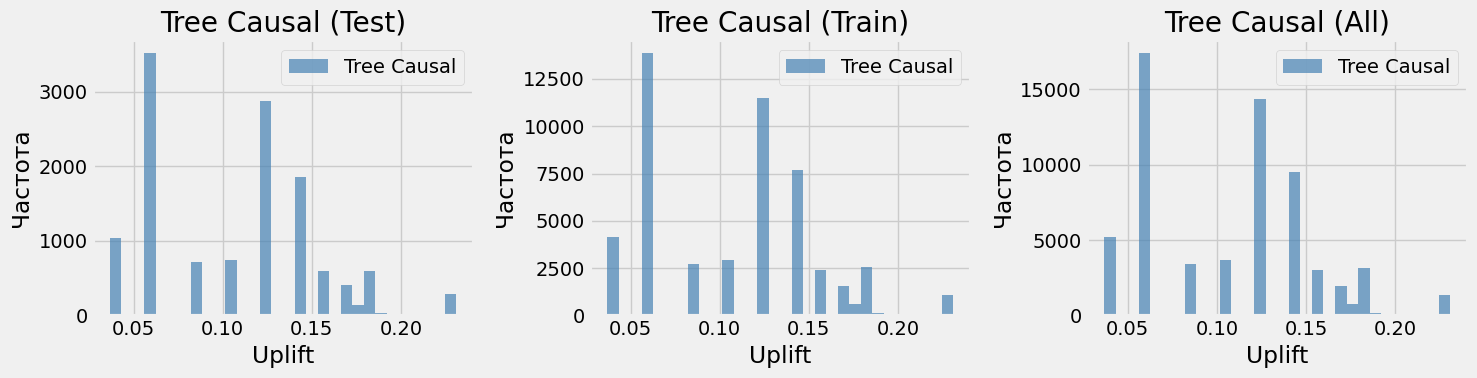

In [13]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(pred_causalml_tree_test, bins=30, alpha=0.7, color='steelblue', label='Tree Causal')
plt.title('Tree Causal (Test)')
plt.xlabel('Uplift')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(pred_causalml_tree_train, bins=30, alpha=0.7, color='steelblue', label='Tree Causal')
plt.title('Tree Causal (Train)')
plt.xlabel('Uplift')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(pred_causalml_tree_all, bins=30, alpha=0.7, color='steelblue', label='Tree Causal')
plt.title('Tree Causal (All)')
plt.xlabel('Uplift')
plt.ylabel('Частота')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
results_test = pd.DataFrame({
    'causalml_test': pred_causalml_tree_test
})

results_train = pd.DataFrame({
    'causalml_train': pred_causalml_tree_train
})

results_all = pd.DataFrame({
    'causalml_all': pred_causalml_tree_all
})
    
actual_treatment_test = np.where(w_test == 1, 'treatment', 'control')
is_control_test = (actual_treatment_test == 'control').astype(int)

gain_df_causalml_test = pd.DataFrame({
    'conversion': y_test.to_numpy(),
    'is_treated': 1 - is_control_test,
    'uplift': results_test['causalml_test']
})

actual_treatment_train = np.where(w_train == 1, 'treatment', 'control')
is_control_train = (actual_treatment_train == 'control').astype(int)

gain_df_causalml_train = pd.DataFrame({
    'conversion': y_train.to_numpy(),
    'is_treated': 1 - is_control_train,
    'uplift': results_train['causalml_train']
})

actual_treatment_all = np.where(w == 1, 'treatment', 'control')
is_control_all = (actual_treatment_all == 'control').astype(int)

gain_df_causalml_all = pd.DataFrame({
    'conversion': y.to_numpy(),
    'is_treated': 1 - is_control_all,
    'uplift': results_all['causalml_all']
})

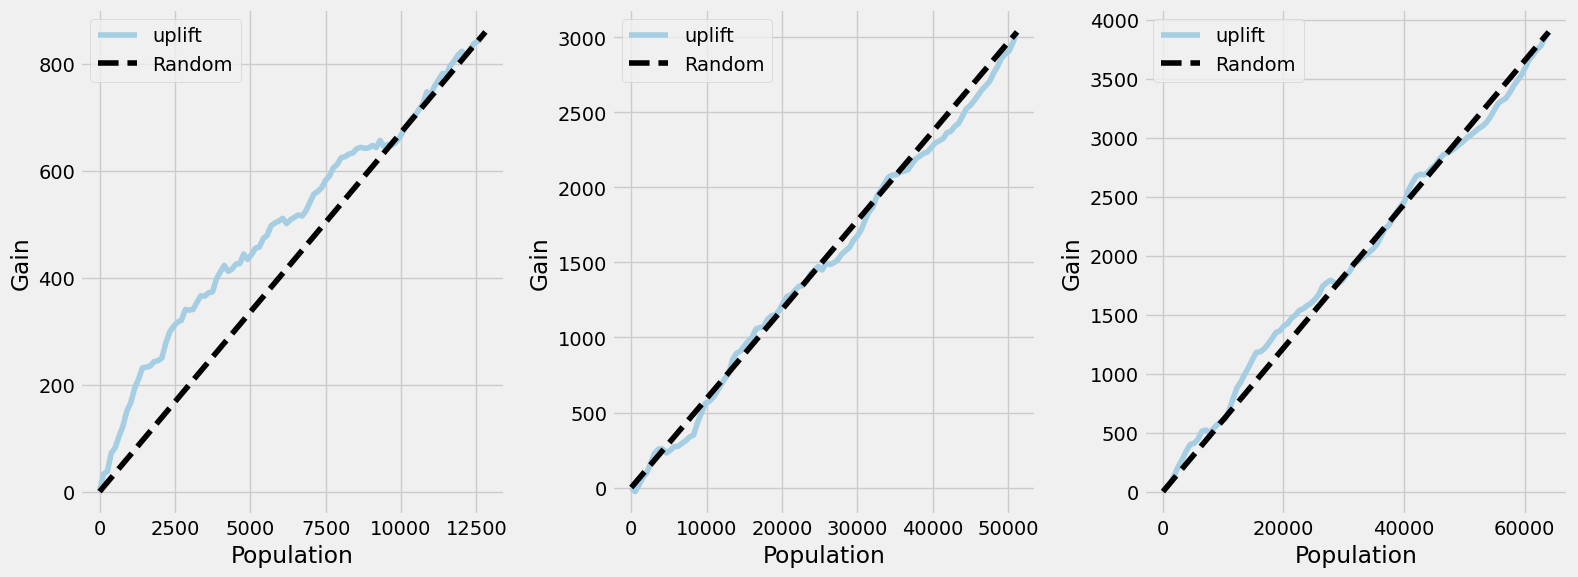

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

plot_gain(gain_df_causalml_test,
          outcome_col='conversion',
          treatment_col='is_treated',
          ax=axes[0])

plot_gain(gain_df_causalml_train,
          outcome_col='conversion',
          treatment_col='is_treated',
          ax=axes[1])

plot_gain(gain_df_causalml_all,
          outcome_col='conversion',
          treatment_col='is_treated',
          ax=axes[2])

plt.tight_layout()
plt.show()

In [16]:
print("=== Финансовый эффект ===")
effect_df = pd.DataFrame({
    'y': y,
    'w': w,
    'uplift': pred_causalml_tree_all
})

top_k = int(0.3 * len(effect_df))
top_df = effect_df.nlargest(top_k, 'uplift')

y_t = top_df[top_df['w'] == 1]['y'].mean()
y_c = top_df[top_df['w'] == 0]['y'].mean()
empirical_uplift = y_t - y_c

n_t = (top_df['w'] == 1).sum()
additional_purchases = empirical_uplift * n_t

print(f"Дополнительные покупки: {additional_purchases:.2f}")

=== Финансовый эффект ===
Дополнительные покупки: 906.03
